In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_DIR ="/content/drive/MyDrive/solar panal image classification/Data"
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    batch_size=BATCH_SIZE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    seed = SEED,
    shuffle = True

)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [5]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    batch_size=BATCH_SIZE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    seed = SEED,
    shuffle = True

)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [6]:
class_names = train_dataset.class_names
num_classes = len(class_names)

In [7]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [8]:
num_classes

6

#Base model(CNN2D)

In [9]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
#convolution layer 1
model.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
#convolution layer 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
#convolution layer 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

#flattening
model.add(tf.keras.layers.Flatten())

#hidden layer(FCL)
model.add(tf.keras.layers.Dense(128, activation='relu'))

#output layer
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
EPOCHS = 10

In [13]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


23/23 ━━━━━━━━━━━━━━━━━━━━ 203s 8s/step - accuracy: 0.2726 - loss: 2.0161 - val_accuracy: 0.2429 - val_loss: 1.7094
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 624ms/step - accuracy: 0.3941 - loss: 1.5250 - val_accuracy: 0.3220 - val_loss: 1.4880
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 558ms/step - accuracy: 0.4986 - loss: 1.3195 - val_accuracy: 0.4463 - val_loss: 1.3348
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 554ms/step - accuracy: 0.6172 - loss: 1.0595 - val_accuracy: 0.6045 - val_loss: 1.1973
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 547ms/step - accuracy: 0.7119 - loss: 0.8460 - val_accuracy: 0.4294 - val_loss: 2.1488
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 510ms/step - accuracy: 0.7698 - loss: 0.7204 - val_accuracy: 0.6384 - val_loss: 1.2054
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 432ms/step - accuracy: 0.8729 - loss: 0.4093 - val_accuracy: 0.6158 - val_loss: 1.2080
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 535ms/step - accuracy: 0.9195 - loss: 0.2540 - val_accuracy: 0.5819 

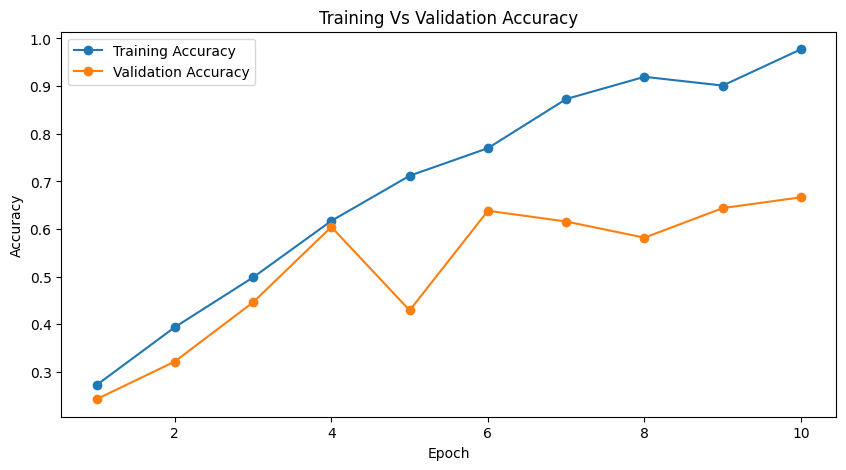

In [14]:
from matplotlib import legend
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1,EPOCHS+1)

plt.figure(figsize=(10,5))
plt.plot(epochs, train_accuracy, label='Training Accuracy',marker = 'o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy',marker = 'o')
plt.title('Training Vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [15]:
EPOCHS = 20
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 521ms/step - accuracy: 0.9831 - loss: 0.0647 - val_accuracy: 0.6497 - val_loss: 1.7569
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 535ms/step - accuracy: 0.9915 - loss: 0.0435 - val_accuracy: 0.6780 - val_loss: 1.6469
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 621ms/step - accuracy: 0.9901 - loss: 0.0310 - val_accuracy: 0.6610 - val_loss: 1.8326
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 604ms/step - accuracy: 0.9958 - loss: 0.0409 - val_accuracy: 0.6554 - val_loss: 1.6634
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 553ms/step - accuracy: 0.9929 - loss: 0.0268 - val_accuracy: 0.6723 - val_loss: 1.7902
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 500ms/step - accuracy: 0.9958 - loss: 0.0226 - val_accuracy: 0.6780 - val_loss: 1.6376
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 401ms/step - accuracy: 0.9915 - loss: 0.0495 - val_accuracy: 0.6497 - val_loss: 1.5572
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 500ms/step - accuracy: 0.9958 - loss: 0.0259 - val_accu

#solve the overfitting problem

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor ='val_loss',patience =3)

In [17]:
from tensorflow.keras.callbacks import LearningRateScheduler

def Schedular(epoch,lr):
  if epochs>5:
    return lr*0.1
  return lr
lr_schedular = LearningRateScheduler(Schedular)

In [18]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
#convolution layer 1
model.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

#convolution layer 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.25))

#convolution layer 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.25))



#flattening
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.3))

#hidden layer(FCL)
model.add(tf.keras.layers.Dense(128, activation='relu'))

#output layer
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [21]:
model.compile(
    optimizer='adam',
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [22]:
EPOCHS = 10
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)


Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 731ms/step - accuracy: 0.7105 - loss: 1.3536 - val_accuracy: 0.1469 - val_loss: 12.4086
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 29s 550ms/step - accuracy: 0.6412 - loss: 1.2373 - val_accuracy: 0.3107 - val_loss: 14.9075
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 469ms/step - accuracy: 0.7429 - loss: 0.9586 - val_accuracy: 0.2825 - val_loss: 13.5972
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 503ms/step - accuracy: 0.7881 - loss: 0.6934 - val_accuracy: 0.2825 - val_loss: 15.7437
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 615ms/step - accuracy: 0.8178 - loss: 0.6745 - val_accuracy: 0.3390 - val_loss: 17.4362
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 504ms/step - accuracy: 0.8277 - loss: 0.5466 - val_accuracy: 0.3898 - val_loss: 14.6302
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 460ms/step - accuracy: 0.8686 - loss: 0.4429 - val_accuracy: 0.3333 - val_loss: 15.5020
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 508ms/step - accuracy: 0.8828 - loss: 0.3799 - v

#Grok;s recommandation

In [25]:
import tensorflow as tf
from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    RandomZoom,
    Rescaling,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    BatchNormalization,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [26]:
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.15),
    RandomZoom(0.15)
    #optional: add randomcontrast (0.2) if colours vary alot
    ])

In [27]:
# -------------------------------
# Data Augmentation (Critical fix)
# -------------------------------


# -------------------------------
# Build the Model
# -------------------------------
model = tf.keras.models.Sequential()

# Input + Augmentation + Rescaling
model.add(data_augmentation)
model.add(Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Conv Block 1
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))  # Extra layer for better features
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Conv Block 2
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Conv Block 3
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.35))

# Classifier
model.add(Flatten())
# Alternative (often better): use GlobalAveragePooling2D() instead of Flatten()
# model.add(GlobalAveragePooling2D())

model.add(Dense(256, activation="relu", kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation="relu", kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output layer
model.add(Dense(num_classes, activation="softmax"))

# -------------------------------
# Compile with lower initial LR
# -------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),  # Reduced from default 1e-3
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------
# Callbacks
# -------------------------------
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,           # More patient now that we have augmentation
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # Halve LR when plateau
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

# -------------------------------
# Train the model
# -------------------------------
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,  # Allow more epochs since early stopping will protect us
    callbacks=callbacks,
    verbose=1
)

# Optional: Print final results
print("\nTraining complete!")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 606ms/step - accuracy: 0.3418 - loss: 2.9741 - val_accuracy: 0.2429 - val_loss: 2.9120 - learning_rate: 3.0000e-04
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 556ms/step - accuracy: 0.4138 - loss: 2.6239 - val_accuracy: 0.1130 - val_loss: 4.9268 - learning_rate: 3.0000e-04
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 552ms/step - accuracy: 0.4322 - loss: 2.5307 - val_accuracy: 0.1130 - val_loss: 6.4415 - learning_rate: 3.0000e-04
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.4864 - loss: 2.3476
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 491ms/step - accuracy: 0.4831 - loss: 2.3851 - val_accuracy: 0.1130 - val_loss: 8.5811 - learning_rate: 3.0000e-04
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 481ms/step - accuracy: 0.4972 - loss: 2.3640 - val_accuracy: 0.1130 - val_loss: 8.7341 - learning_rate: 1.5000e-04
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 586ms/step - accuracy: 0.4746 - l

#Transfer learning :MobileNetv2

In [29]:
# MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [30]:
base_model.trainable = False

model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_augmentation)
model.add(tf.keras.layers.Rescaling(1.0/255))

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [31]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 650ms/step - accuracy: 0.4915 - loss: 1.4310 - val_accuracy: 0.5989 - val_loss: 1.1220
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 467ms/step - accuracy: 0.6992 - loss: 0.8815 - val_accuracy: 0.5763 - val_loss: 1.0545
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 472ms/step - accuracy: 0.7288 - loss: 0.7866 - val_accuracy: 0.6497 - val_loss: 0.9599
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 553ms/step - accuracy: 0.7768 - loss: 0.6387 - val_accuracy: 0.6893 - val_loss: 0.8511
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 521ms/step - accuracy: 0.7966 - loss: 0.5970 - val_accuracy: 0.6780 - val_loss: 0.8314
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 526ms/step - accuracy: 0.8079 - loss: 0.5334 - val_accuracy: 0.7006 - val_loss: 0.8473
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 528ms/step - accuracy: 0.8121 - loss: 0.5107 - val_accuracy: 0.7345 - val_loss: 0.7726
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 536ms/step - accuracy: 0.8390 - loss: 0.4587 - val_accu

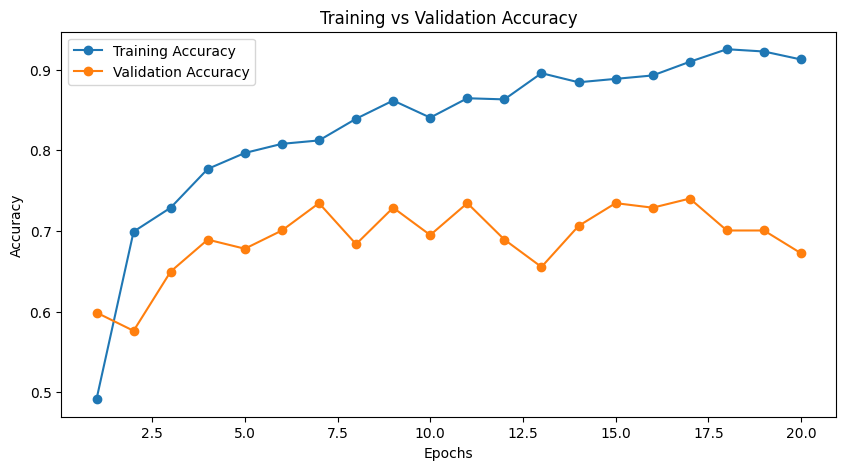

In [34]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, 21)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [38]:
model.save('/content/drive/MyDrive/solar panal image classification/my_model.keras')

## EfficientNet

In [39]:
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

In [40]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="training",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [41]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="validation",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [42]:
class_names = train_dataset.class_names

In [44]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [45]:
num_classes = len(class_names)

In [49]:
import os

class_counts = {}
total_images = 0

for class_name in class_names:
  class_path = os.path.join(DATASET_DIR, class_name)
  count = len(os.listdir(class_path))
  class_counts[class_name] = count
  total_images += count

In [50]:
class_weights = {}

for index, class_name in enumerate(class_names):
  class_weights[index] = total_images / (num_classes * class_counts[class_name])

print("Class weights", class_weights)

Class weights {0: 0.7530224525043178, 1: 0.7491408934707904, 2: 0.7649122807017544, 3: 1.4110032362459546, 4: 2.106280193236715, 5: 1.1815718157181572}


In [51]:
data_augmentation = tf.keras.Sequential()
data_augmentation.add(tf.keras.layers.RandomFlip("horizontal"))
data_augmentation.add(tf.keras.layers.RandomRotation(0.1))
data_augmentation.add(tf.keras.layers.RandomZoom(0.1))

In [52]:
train_images = []
train_labels = []

In [53]:
for images, labels in train_dataset:
  images = preprocess_input(images)
  train_images.append(images)
  train_labels.append(labels)

In [54]:
train_images = tf.concat(train_images, axis=0)
train_labels = tf.concat(train_labels, axis=0)

In [55]:
validation_images = []
validation_labels = []

In [56]:
for images, labels in validation_dataset:
  images = preprocess_input(images)
  validation_images.append(images)
  validation_labels.append(labels)

In [57]:
validation_images = tf.concat(validation_images, axis=0)
validation_labels = tf.concat(validation_labels, axis=0)

In [58]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape = (224,224,3),
    include_top = False,
    weights="imagenet"
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [59]:
base_model.trainable = False

In [60]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(data_augmentation)

model.add(base_model)
model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [61]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [62]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_7 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [63]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = 15
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 675ms/step - accuracy: 0.5508 - loss: 1.2323 - val_accuracy: 0.6610 - val_loss: 0.9415
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 533ms/step - accuracy: 0.7669 - loss: 0.7217 - val_accuracy: 0.7175 - val_loss: 0.7802
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 596ms/step - accuracy: 0.8079 - loss: 0.5869 - val_accuracy: 0.7006 - val_loss: 0.7603
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 554ms/step - accuracy: 0.8333 - loss: 0.4833 - val_accuracy: 0.7740 - val_loss: 0.6600
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 504ms/step - accuracy: 0.8573 - loss: 0.4205 - val_accuracy: 0.7740 - val_loss: 0.6721
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 542ms/step - accuracy: 0.8828 - loss: 0.3688 - val_accuracy: 0.7627 - val_loss: 0.6750
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 520ms/step - accuracy: 0.9054 - loss: 0.3172 - val_accuracy: 0.7514 - val_loss: 0.6434
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 511ms/step - accuracy: 0.8983 - loss: 0.3160 - val_accu

## Hyper Parameter Optimization


In [67]:
!pip install keras-tuner  # Run if not installed

import keras_tuner as kt
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Reuse your train_dataset and validation_dataset (with preprocess_input already applied)
# Make sure they are defined as in your original code

def build_model(hp):
    base_model = EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    model = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(hp.Float("rotation_factor", min_value=0.05, max_value=0.3, step=0.05)),
        RandomZoom(hp.Float("zoom_factor", min_value=0.05, max_value=0.3, step=0.05)),
        base_model,
        GlobalAveragePooling2D(),
        Dropout(hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)),
        Dense(
            hp.Int("dense_units", min_value=64, max_value=512, step=64),
            activation='relu'
        ),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Setup Random Search Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,          # Same as n_iter before
    executions_per_trial=1,
    directory='kt_dir',
    project_name='efficientnet_tune',
    overwrite=True
)

# Optional: Early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Run the search
tuner.search(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stopping],
    class_weight=class_weights  # Handles imbalance
)

# Results
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hps.values)

best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate on validation
val_loss, val_acc = best_model.evaluate(validation_dataset)
print(f"Best validation accuracy: {val_acc:.4f}")

Trial 20 Complete [00h 03m 11s]
val_accuracy: 0.7853107452392578

Best val_accuracy So Far: 0.8248587846755981
Total elapsed time: 01h 15m 13s
Best hyperparameters:
{'rotation_factor': 0.05, 'zoom_factor': 0.2, 'dropout_rate': 0.0, 'dense_units': 320, 'learning_rate': 0.004423920770740319}
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 457ms/step - accuracy: 0.8249 - loss: 0.6828
Best validation accuracy: 0.8249


In [66]:
best_model.save('/content/drive/MyDrive/solar panal image classification/trained_effnet_finetune.h5')